# CNN for Galaxy Property Regression



**Primary target:** `LogMass`  
This is a good first property to infer from the image because it is strongly linked to galaxy structure and is relatively learnable from RGB imaging.

We can later reuse the same pipeline for other targets such as `nsa_sersic_n`, `nsa_sersic_ba`, `vel_sigma_Re`, or a multi-output model.

In [4]:
pip install torch torchvision torchaudio

  Using cached torchvision-0.27.0-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
Using cached torchvision-0.27.0-cp313-cp313-win_amd64.whl (4.1 MB)
Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
    --------------------------------------- 1.6/123.0 MB 9.5 MB/s eta 0:00:13
   - -------------------------------------- 5.0/123.0 MB 13.3 MB/s eta 0:00:09
   -- ------------------------------------- 9.2/123.0 MB 15.9 MB/s eta 0:00:08
   ---- ----------------------------------- 12.6/123.0 MB 16.0 MB/s eta 0:00:07
   ----- ---------------------------------- 16.0/123.0 MB 16.1 MB/s eta 0:00:07
   ------ --------------------------------- 20.4/123.0 MB 17.0 MB/s eta 0:00:07
   -------- ------------------------------- 26.5/123.0 MB 18.8 MB/s eta 0:00:06
   ---------- ----------------------------- 32.5/123.0 MB 20.2 MB/s eta 0:00:05
   ------------ --------------------------- 39.3/123.0 MB 21.7 MB/s eta 0:00:04
  

In [5]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
from torchvision import models

print('PyTorch:', torch.__version__)
print('TorchVision loaded')

PyTorch: 2.12.0+cpu
TorchVision loaded


In [6]:
# -----------------------------
# Paths and configuration
# -----------------------------
CSV_PATH = r'./inferencia.csv'   # change if needed
IMAGE_DIR = r'C:\Users\Alejandro Mondragon\Documents\Tec\Integrador\Imagenes'

TARGET_COL = 'LogMass'          # start here
IMAGE_EXT = '.jpg'

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0                 # set >0 if your environment supports it well
RANDOM_SEED = 42

TRAIN_FRAC = 0.8
VAL_FRAC = 0.1
TEST_FRAC = 0.1

EPOCHS = 8
LR = 1e-4

assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1.0) < 1e-9

In [7]:
# -----------------------------
# Load CSV and keep only rows with an existing image
# -----------------------------
df = pd.read_csv(CSV_PATH)
df['image_path'] = df['name'].astype(str).apply(lambda x: os.path.join(IMAGE_DIR, x + IMAGE_EXT))

exists_mask = df['image_path'].apply(os.path.exists)
missing = (~exists_mask).sum()

df = df.loc[exists_mask].reset_index(drop=True)

print(f'Rows in CSV: {len(pd.read_csv(CSV_PATH))}')
print(f'Rows with existing images: {len(df)}')
print(f'Missing images skipped: {missing}')
print(df[["name", TARGET_COL, "image_path"]].head())

Rows in CSV: 10126
Rows with existing images: 10126
Missing images skipped: 0
                name    LogMass  \
0  manga-10001-12701   9.486857   
1  manga-10001-12702   9.727675   
2  manga-10001-12703  10.136514   
3  manga-10001-12704   9.632117   
4  manga-10001-12705  10.113519   

                                          image_path  
0  C:\Users\Alejandro Mondragon\Documents\Tec\Int...  
1  C:\Users\Alejandro Mondragon\Documents\Tec\Int...  
2  C:\Users\Alejandro Mondragon\Documents\Tec\Int...  
3  C:\Users\Alejandro Mondragon\Documents\Tec\Int...  
4  C:\Users\Alejandro Mondragon\Documents\Tec\Int...  


In [8]:
# -----------------------------
# Train / val / test split
# -----------------------------
rng = np.random.default_rng(RANDOM_SEED)
perm = rng.permutation(len(df))
df = df.iloc[perm].reset_index(drop=True)

n_total = len(df)
n_train = int(n_total * TRAIN_FRAC)
n_val = int(n_total * VAL_FRAC)
n_test = n_total - n_train - n_val

df_train = df.iloc[:n_train].reset_index(drop=True)
df_val = df.iloc[n_train:n_train + n_val].reset_index(drop=True)
df_test = df.iloc[n_train + n_val:].reset_index(drop=True)

print('Split sizes:', len(df_train), len(df_val), len(df_test))

target_mean = df_train[TARGET_COL].mean()
target_std = df_train[TARGET_COL].std()

print('Target mean/std (train only):', target_mean, target_std)

Split sizes: 8100 1012 1014
Target mean/std (train only): 10.162696517515958 0.7187265028115847


In [9]:
# -----------------------------
# Transforms
# For galaxies, random flips and rotations are usually safe because orientation is arbitrary.
# -----------------------------
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(degrees=180),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

In [10]:
class GalaxyRegressionDataset(Dataset):
    def __init__(self, dataframe, target_col, image_col='image_path', transform=None, target_mean=None, target_std=None):
        self.df = dataframe.reset_index(drop=True)
        self.target_col = target_col
        self.image_col = image_col
        self.transform = transform
        self.target_mean = target_mean
        self.target_std = target_std if target_std not in (None, 0) else 1.0

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row[self.image_col]).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)

        y = float(row[self.target_col])
        y = (y - self.target_mean) / self.target_std
        y = torch.tensor(y, dtype=torch.float32)
        return img, y


train_ds = GalaxyRegressionDataset(df_train, TARGET_COL, transform=train_transform,
                                    target_mean=target_mean, target_std=target_std)
val_ds = GalaxyRegressionDataset(df_val, TARGET_COL, transform=eval_transform,
                                  target_mean=target_mean, target_std=target_std)
test_ds = GalaxyRegressionDataset(df_test, TARGET_COL, transform=eval_transform,
                                   target_mean=target_mean, target_std=target_std)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print('DataLoaders ready')

DataLoaders ready


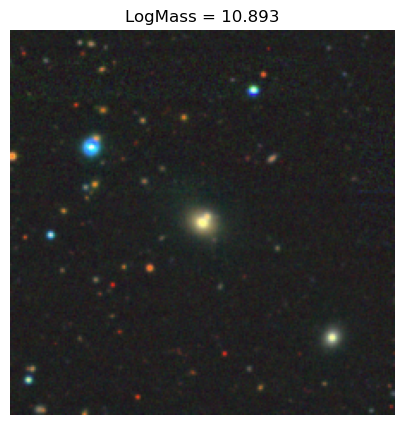

In [11]:
# -----------------------------
# Visualize one sample
# -----------------------------
def denormalize_img(x):
    x = x.clone()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    x = x * std + mean
    return torch.clamp(x, 0, 1)

idx = np.random.randint(len(test_ds))
img, y = test_ds[idx]
raw_y = y.item() * target_std + target_mean

plt.figure(figsize=(5, 5))
plt.imshow(denormalize_img(img).permute(1, 2, 0))
plt.title(f'{TARGET_COL} = {raw_y:.3f}')
plt.axis('off')
plt.show()

In [12]:
# -----------------------------
# Device
# -----------------------------
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Using device:', device)

Using device: cpu


In [13]:
# -----------------------------
# Model: transfer learning with ResNet-18
# Output is a single scalar for regression.
# -----------------------------
weights = models.ResNet18_Weights.DEFAULT
base_model = models.resnet18(weights=weights)

for p in base_model.parameters():
    p.requires_grad = False

base_model.fc = nn.Linear(base_model.fc.in_features, 1)

model = base_model.to(device)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [14]:
# -----------------------------
# Loss, optimizer, metrics
# -----------------------------
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=LR)

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2) + 1e-12
    r2 = 1 - ss_res / ss_tot
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds_raw = []
    targets_raw = []

    for x, y in loader:
        x = x.to(device=device, dtype=torch.float32)
        y = y.to(device=device, dtype=torch.float32).view(-1, 1)

        out = model(x)
        out = out.cpu().numpy().reshape(-1)
        y = y.cpu().numpy().reshape(-1)

        out_raw = out * target_std + target_mean
        y_raw = y * target_std + target_mean

        preds_raw.extend(out_raw.tolist())
        targets_raw.extend(y_raw.tolist())

    return regression_metrics(targets_raw, preds_raw)

def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0

    for x, y in loader:
        x = x.to(device=device, dtype=torch.float32)
        y = y.to(device=device, dtype=torch.float32).view(-1, 1)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

    return running_loss / len(loader.dataset)

In [ ]:
# -----------------------------
# Training loop
# -----------------------------
history = {'train_loss': [], 'val_mae': [], 'val_rmse': [], 'val_r2': []}

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_metrics = evaluate(model, val_loader)

    history['train_loss'].append(train_loss)
    history['val_mae'].append(val_metrics['mae'])
    history['val_rmse'].append(val_metrics['rmse'])
    history['val_r2'].append(val_metrics['r2'])

    print(
        f'Epoch {epoch+1:02d}/{EPOCHS} | '
        f'train_loss={train_loss:.4f} | '
        f'val_MAE={val_metrics["mae"]:.4f} | '
        f'val_RMSE={val_metrics["rmse"]:.4f} | '
        f'val_R2={val_metrics["r2"]:.4f}'
    )

In [ ]:
# -----------------------------
# Final test evaluation
# -----------------------------
test_metrics = evaluate(model, test_loader)
print('Test metrics:', test_metrics)

In [ ]:
# -----------------------------
# Plot training curves
# -----------------------------
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(history['train_loss'])
ax[0].set_title('Train Loss')
ax[0].set_xlabel('Epoch')

ax[1].plot(history['val_mae'])
ax[1].set_title('Validation MAE')
ax[1].set_xlabel('Epoch')

ax[2].plot(history['val_r2'])
ax[2].set_title('Validation R2')
ax[2].set_xlabel('Epoch')

plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------
# Show predictions vs truth on a few test galaxies
# -----------------------------
@torch.no_grad()
def predict_loader(model, loader, n_show=12):
    model.eval()
    preds = []
    trues = []

    for x, y in loader:
        x = x.to(device=device, dtype=torch.float32)
        out = model(x).cpu().numpy().reshape(-1)
        y = y.numpy().reshape(-1)

        out = out * target_std + target_mean
        y = y * target_std + target_mean

        preds.extend(out.tolist())
        trues.extend(y.tolist())

    preds = np.array(preds)
    trues = np.array(trues)

    n_show = min(n_show, len(preds))
    plt.figure(figsize=(6, 6))
    plt.scatter(trues[:n_show], preds[:n_show])
    lims = [min(trues[:n_show].min(), preds[:n_show].min()), max(trues[:n_show].max(), preds[:n_show].max())]
    plt.plot(lims, lims)
    plt.xlabel('True LogMass')
    plt.ylabel('Predicted LogMass')
    plt.title('Prediction check')
    plt.show()

predict_loader(model, test_loader)

## Next targets to try

Once `LogMass` is working, the same pipeline can be re-run with:

- `nsa_sersic_n`  → morphology concentration
- `nsa_sersic_ba` → axis ratio / inclination
- `vel_sigma_Re`  → velocity dispersion
- `log_SFR_Ha` or `log_SFR_ssp` → star formation rate

For a stronger model later, we can also switch from a single-output regressor to a **multi-task model** that predicts several properties at once.